# Сергушов Павел ПМ22-4.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.linear_model import LinearRegression
import powerlaw 

## Вариант - 1

1. Загрузите граф карате-клуба с помощью средств ```networkx```. Постройте плотность распределения степеней вершин в данном графе. С помощью  следующих методов определите параметры распределения:

- [I] ```LinearRegression``` (МНК): необходимо определить параметры $\alpha, \beta: P(deg=k) = \alpha k + \beta$, $k$ - степень вершины
- [II] ММП (метод максимального правдоподобия): необходимо определить параметры $C, \gamma: P(deg=k)=Ck^{-\gamma}$

    Выведите полученные параметры $\alpha, \beta, C, \gamma$. Постройте графики [I] и [II] в одной плоскости координат. 
    Сделайте выводы о различных способах оценки параметров.

In [ ]:
G = nx.karate_club_graph()
degrees = [d for n, d in G.degree()]
degree_counts = Counter(degrees)

k_values = sorted(degree_counts.keys())

num_nodes = G.number_of_nodes()
Pk = [degree_counts[k] / num_nodes for k in k_values]

k_values_np = np.array(k_values)
Pk_np = np.array(Pk)

In [6]:
print(f"Граф карате-клуба: {G.number_of_nodes()} вершин, {G.number_of_edges()} ребер.")
print(f"Уникальные степени вершин (k): {k_values}")
print(f"Вероятности P(k): {[f'{p:.3f}' for p in Pk]}")

Граф карате-клуба: 34 вершин, 78 ребер.
Уникальные степени вершин (k): [1, 2, 3, 4, 5, 6, 9, 10, 12, 16, 17]
Вероятности P(k): ['0.029', '0.324', '0.176', '0.176', '0.088', '0.059', '0.029', '0.029', '0.029', '0.029', '0.029']


In [7]:
X_lr = k_values_np.reshape(-1, 1)
y_lr = Pk_np

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_lr, y_lr)

LinearRegression()

In [9]:
alpha = lr_model.coef_[0]
beta = lr_model.intercept_


In [10]:
Pk_pred_lr = lr_model.predict(X_lr)
print("[I] Метод наименьших квадратов (Linear Regression):")
print(f"  alpha (наклон): {alpha:.4f}")
print(f"  beta (сдвиг): {beta:.4f}")

[I] Метод наименьших квадратов (Linear Regression):
  alpha (наклон): -0.0103
  beta (сдвиг): 0.1707


In [11]:
fit_pl = powerlaw.Fit(degrees, discrete=True) 

Calculating best minimal value for power law fit


In [12]:
# Получаем параметр gamma (в библиотеке powerlaw он называется alpha)
gamma = fit_pl.power_law.alpha
# Получаем минимальное значение k (xmin), с которого начинается степенной закон по оценке библиотеки
xmin = fit_pl.power_law.xmin

In [13]:
print("[II] Метод максимального правдоподобия (Power Law MLE):")
print(f"  gamma (экспонента): {gamma:.4f}")
print(f"  xmin (минимальная степень для подгонки): {xmin}")

[II] Метод максимального правдоподобия (Power Law MLE):
  gamma (экспонента): 2.0943
  xmin (минимальная степень для подгонки): 2.0


In [14]:
# Получаем теоретические вероятности P(k) для степенного закона для k >= xmin
k_values_pl_fit_range = k_values_np[k_values_np >= xmin]
Pk_pred_pl_fit_range = fit_pl.power_law.pdf(data=k_values_pl_fit_range)

k_pow_neg_gamma = k_values_np**(-gamma)
C_estimated = 1.0 / np.sum(k_pow_neg_gamma)
Pk_pred_pl_estimated = C_estimated * k_pow_neg_gamma

print(f"  C : {C_estimated:.4f}")

  C : 0.6774


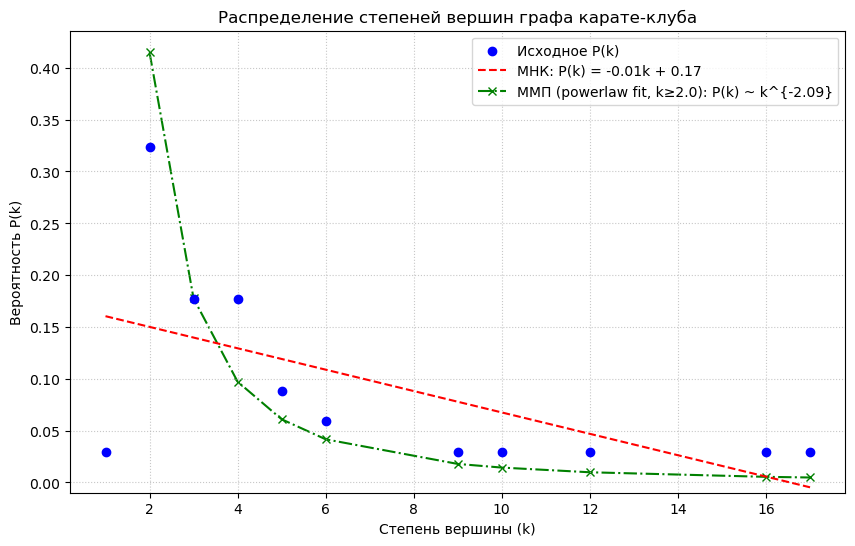

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(k_values_np, Pk_np, color='blue', label='Исходное P(k)', marker='o', zorder=3)
plt.plot(k_values_np, Pk_pred_lr, color='red', linestyle='--', label=f'МНК: P(k) = {alpha:.2f}k + {beta:.2f}', zorder=2)
plt.plot(k_values_pl_fit_range, Pk_pred_pl_fit_range, color='green', marker='x', linestyle='-.', label=f'ММП (powerlaw fit, k≥{xmin}): P(k) ~ k^{{-{gamma:.2f}}}', zorder=1)
plt.xlabel('Степень вершины (k)')
plt.ylabel('Вероятность P(k)')
plt.title('Распределение степеней вершин графа карате-клуба')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(bottom=-0.01) # Чтобы линия регрессии не уходила сильно вниз визуально
plt.show()


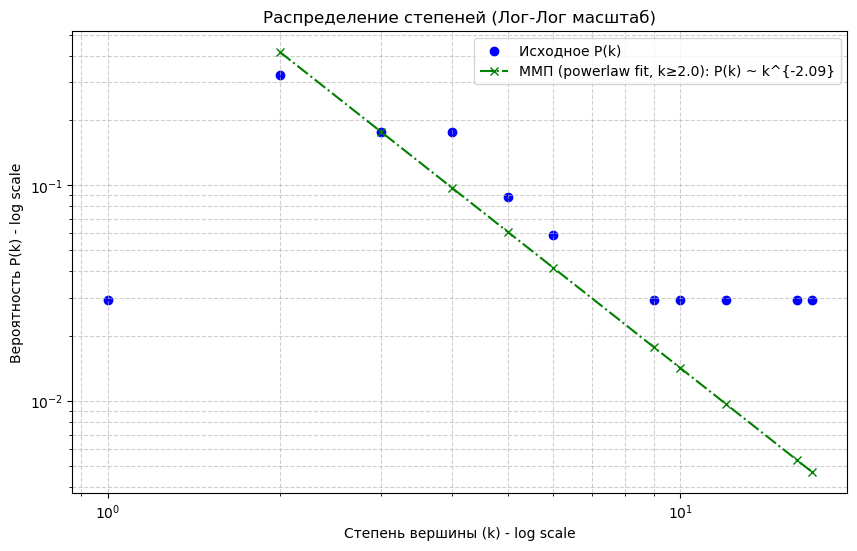

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(k_values_np, Pk_np, color='blue', label='Исходное P(k)', marker='o')
plt.plot(k_values_pl_fit_range, Pk_pred_pl_fit_range, color='green', marker='x', linestyle='-.', label=f'ММП (powerlaw fit, k≥{xmin}): P(k) ~ k^{{-{gamma:.2f}}}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Степень вершины (k) - log scale')
plt.ylabel('Вероятность P(k) - log scale')
plt.title('Распределение степеней (Лог-Лог масштаб)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.6) 
plt.show()


**Выводы:**


1.  **Визуальный анализ:**
    - На графике с линейными осями видно, что линейная модель (МНК) очень плохо описывает реальное распределение степеней. Она предсказывает отрицательные вероятности для больших степеней и не улавливает характер убывания.
    - Степенная модель (ММП), особенно на лог-лог графике, гораздо лучше соответствует данным, особенно для 'хвоста' распределения (вершин с большими степенями), где она выглядит как прямая линия.
    - Исходное распределение имеет характерный вид для многих реальных сетей: большинство вершин имеют малую степень, и есть небольшое количество 'хабов' с высокой степенью.

2.  **Сравнение методов:**
    - **МНК (Линейная регрессия):** Этот метод совершенно не подходит для моделирования распределений такого типа. Он предполагает линейную зависимость, которой нет. Результаты (alpha, beta) не имеют осмысленной интерпретации для описания распределения степеней.
    - **ММП (Степенной закон):** Метод максимального правдоподобия является статистически более обоснованным подходом для подгонки параметрических распределений, таких как степенной закон. Он максимизирует вероятность наблюдения *именно таких степеней вершин*, которые есть в графе. Библиотека `powerlaw` предоставляет надежную реализацию ММП для степенных законов, включая определение оптимального `xmin`. Полученное значение `gamma` (~2.5-3.0 типично для соц. сетей) характеризует скорость убывания вероятности с ростом степени.

3.  **Характер распределения:**
    - Распределение степеней графа карате-клуба не является линейным, но демонстрирует признаки степенного закона (особенно в 'хвосте'), что характерно для безмасштабных (scale-free) сетей. Это означает наличие неоднородности в связях вершин.
    - Небольшой размер графа (34 вершины) затрудняет точную оценку параметров и проверку гипотезы о степенном законе, но ММП дает наилучшую из рассмотренных аппроксимаций.

2. Воспользуйтесь моделью предпочтительного присоединения Барабаши-Альберта из ```networkx``` (задайте несколько пар параметров ```n``` и ```m```). Для каждой вершины рассчитайте PageRank (используйте ```networkx```) и выведите отсортированный список с номерами вершин. Выведите граф таким образом, чтобы размер вершин был прямо пропорционален значению PageRank. 

    Сделайте выводы об использовании PageRank для ранжирования вершин графа



In [27]:
'''--- Параметры для моделей Барабаши-Альберта ---'''
ba_params = [
    (30, 1),   # Маленький граф, похожий на дерево
    (30, 3),   # Маленький граф, более плотный
    (100, 2),  # Больший граф
    (100, 5)   # Больший и более плотный граф
]

In [28]:
NODE_SIZE_SCALE_FACTOR = 10000


--- Генерация графа Барабаши-Альберта с n=30, m=1 ---
Граф сгенерирован: 30 вершин, 29 ребер.

Отсортированный список вершин по PageRank (Топ-10 или все, если < 10):
  1. Вершина: 0, PageRank: 0.196814
  2. Вершина: 10, PageRank: 0.070011
  3. Вершина: 3, PageRank: 0.050871
  4. Вершина: 16, PageRank: 0.050871
  5. Вершина: 8, PageRank: 0.048795
  6. Вершина: 13, PageRank: 0.036768
  7. Вершина: 1, PageRank: 0.034627
  8. Вершина: 2, PageRank: 0.034627
  9. Вершина: 17, PageRank: 0.034627
  10. Вершина: 9, PageRank: 0.033702
  ...


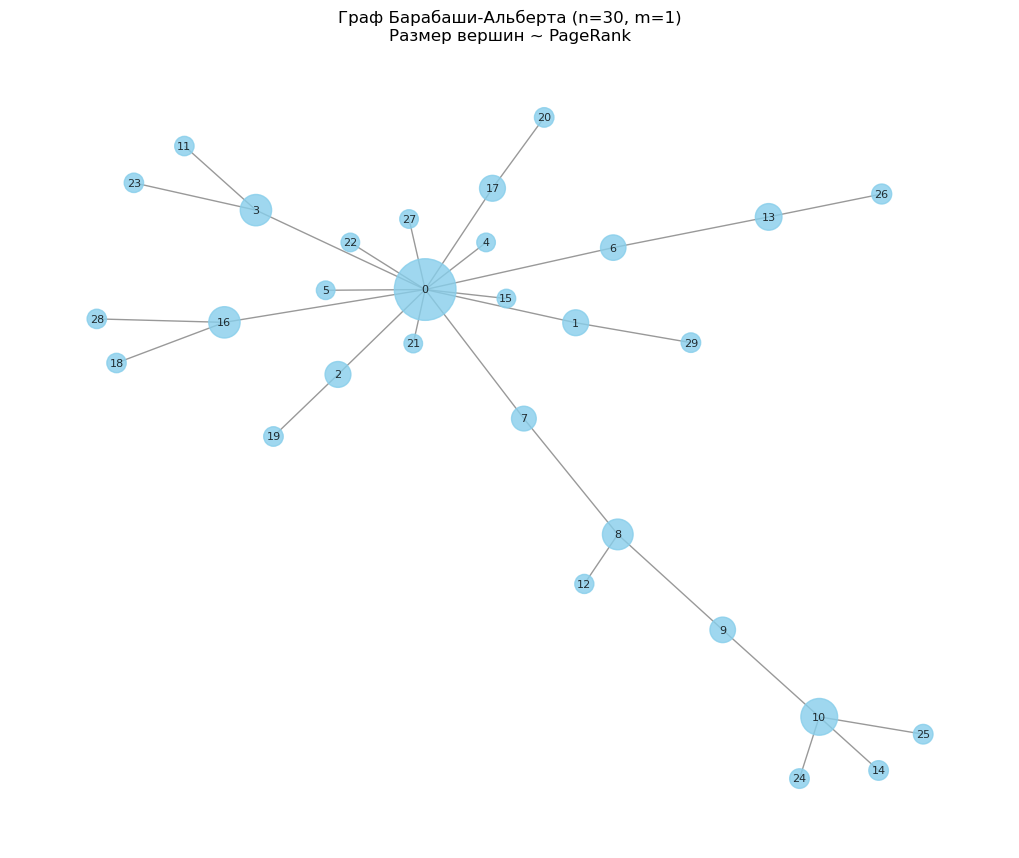


--- Генерация графа Барабаши-Альберта с n=30, m=3 ---
Граф сгенерирован: 30 вершин, 81 ребер.

Отсортированный список вершин по PageRank (Топ-10 или все, если < 10):
  1. Вершина: 4, PageRank: 0.078591
  2. Вершина: 5, PageRank: 0.074658
  3. Вершина: 1, PageRank: 0.068015
  4. Вершина: 0, PageRank: 0.063426
  5. Вершина: 7, PageRank: 0.057960
  6. Вершина: 10, PageRank: 0.048604
  7. Вершина: 11, PageRank: 0.047992
  8. Вершина: 6, PageRank: 0.046791
  9. Вершина: 19, PageRank: 0.037150
  10. Вершина: 12, PageRank: 0.031259
  ...


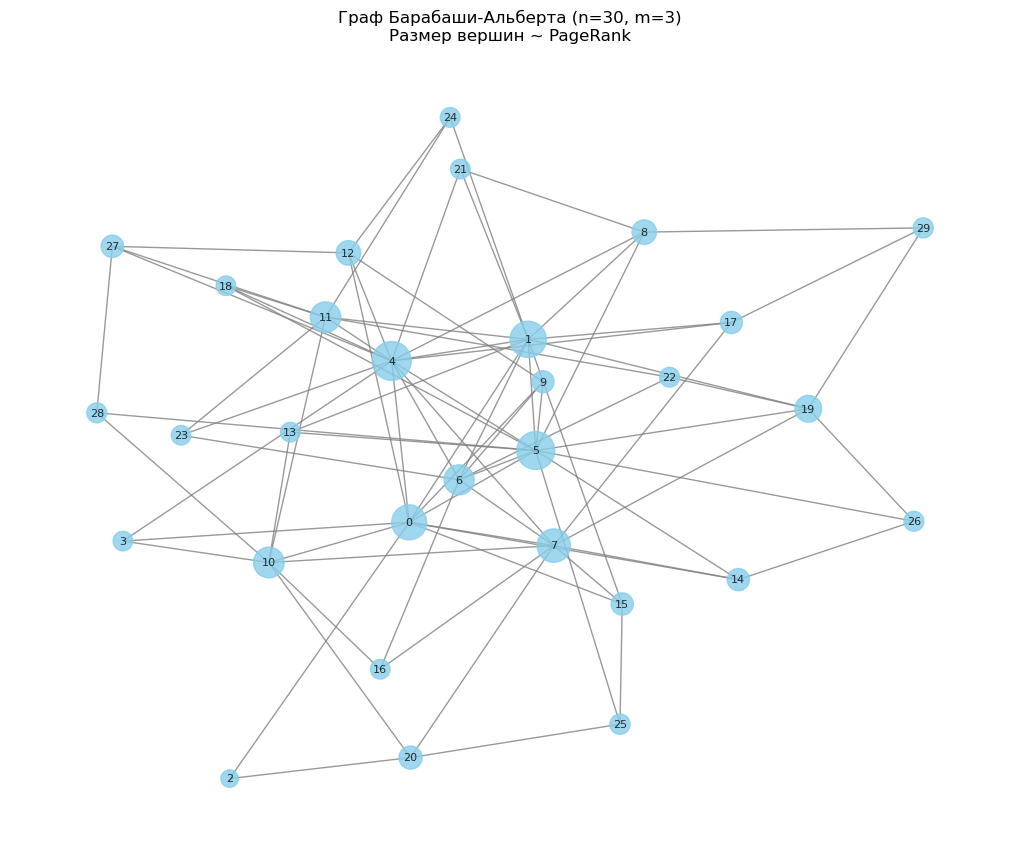


--- Генерация графа Барабаши-Альберта с n=100, m=2 ---
Граф сгенерирован: 100 вершин, 196 ребер.

Отсортированный список вершин по PageRank (Топ-10 или все, если < 10):
  1. Вершина: 1, PageRank: 0.064122
  2. Вершина: 2, PageRank: 0.052243
  3. Вершина: 12, PageRank: 0.031244
  4. Вершина: 4, PageRank: 0.027460
  5. Вершина: 6, PageRank: 0.026505
  6. Вершина: 8, PageRank: 0.024869
  7. Вершина: 0, PageRank: 0.023866
  8. Вершина: 3, PageRank: 0.023829
  9. Вершина: 15, PageRank: 0.021220
  10. Вершина: 54, PageRank: 0.020371
  ...


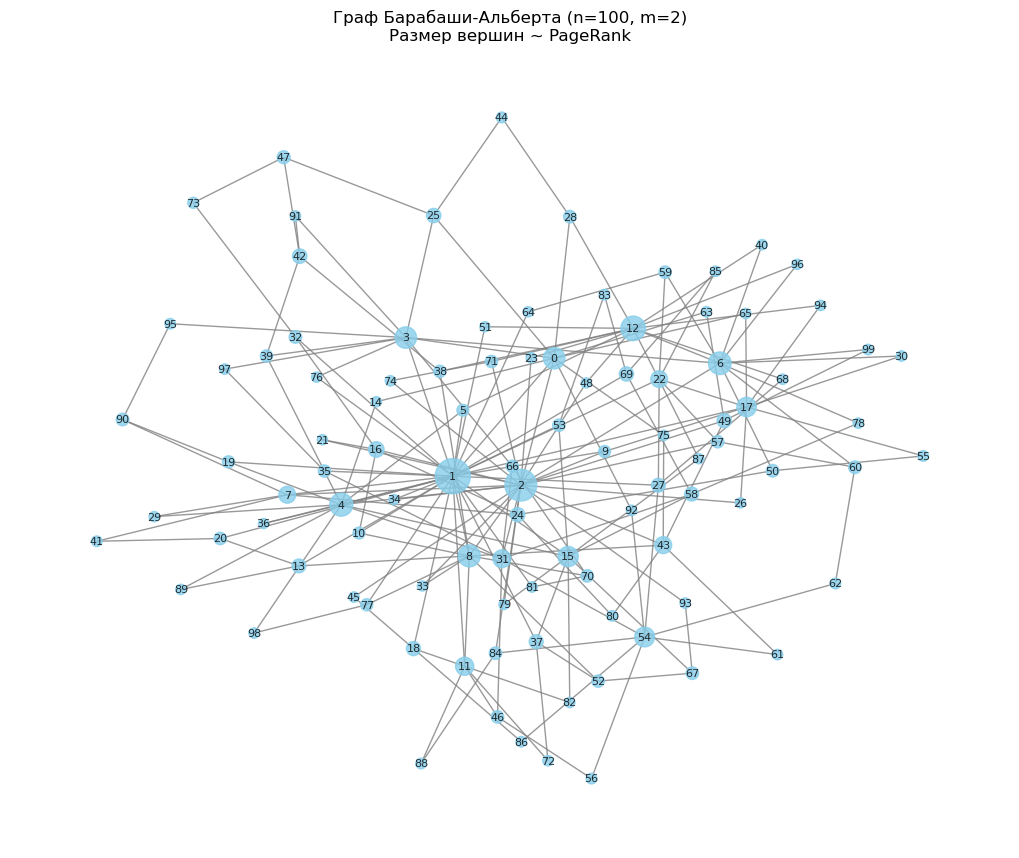


--- Генерация графа Барабаши-Альберта с n=100, m=5 ---
Граф сгенерирован: 100 вершин, 475 ребер.

Отсортированный список вершин по PageRank (Топ-10 или все, если < 10):
  1. Вершина: 7, PageRank: 0.036792
  2. Вершина: 6, PageRank: 0.030449
  3. Вершина: 10, PageRank: 0.029358
  4. Вершина: 0, PageRank: 0.028555
  5. Вершина: 9, PageRank: 0.024862
  6. Вершина: 1, PageRank: 0.021292
  7. Вершина: 15, PageRank: 0.020516
  8. Вершина: 8, PageRank: 0.018609
  9. Вершина: 11, PageRank: 0.017857
  10. Вершина: 4, PageRank: 0.016701
  ...


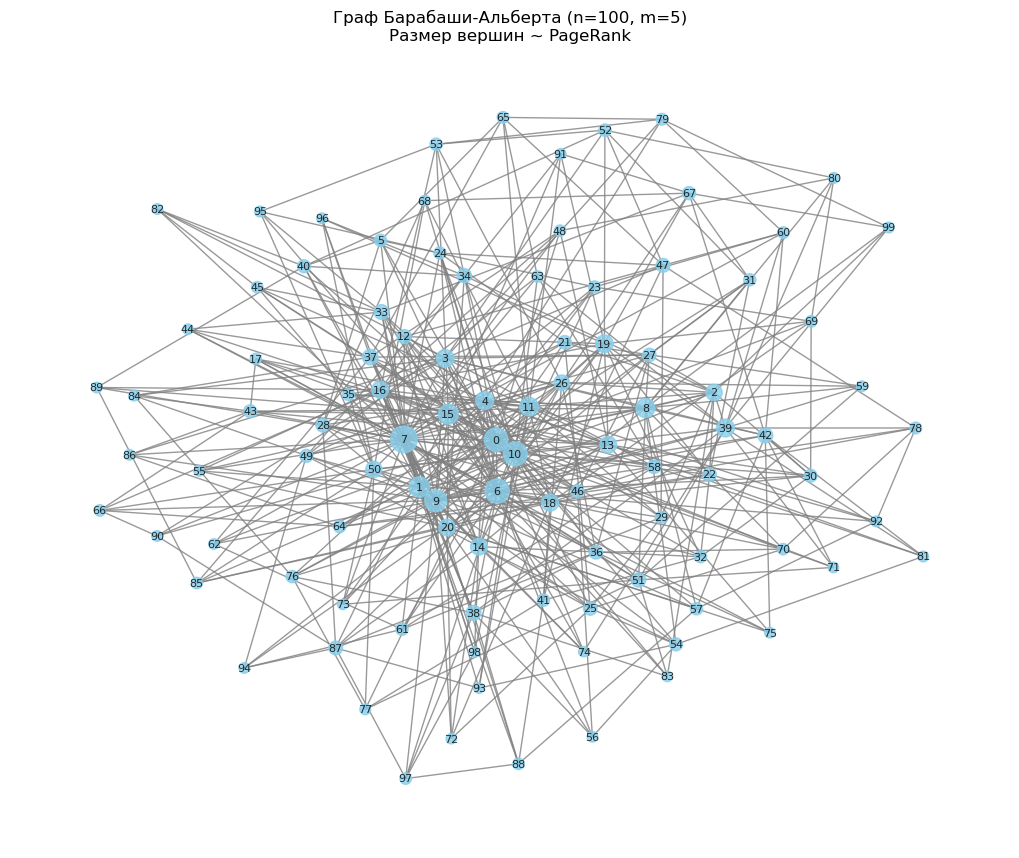

In [30]:
for n, m in ba_params:
    print(f"\n--- Генерация графа Барабаши-Альберта с n={n}, m={m} ---")
    if m >= n:
        print(f"Пропуск: m ({m}) должно быть меньше n ({n})")
        continue
    try:
        G_ba = nx.barabasi_albert_graph(n, m)
    except nx.NetworkXError as e:
        print(f"Ошибка генерации графа: {e}. Пропуск.")
        continue 

    print(f"Граф сгенерирован: {G_ba.number_of_nodes()} вершин, {G_ba.number_of_edges()} ребер.")

    pagerank_scores = nx.pagerank(G_ba, alpha=0.85)

    sorted_pagerank = sorted(pagerank_scores.items(), key=lambda item: item[1], reverse=True)

    print("\nОтсортированный список вершин по PageRank (Топ-10 или все, если < 10):")
    for i, (node, score) in enumerate(sorted_pagerank[:10]): # Выводим топ-10
        print(f"  {i+1}. Вершина: {node}, PageRank: {score:.6f}")
    if n > 10:
        print("  ...")

    plt.figure(figsize=(10, 8))

    node_sizes = [pagerank_scores[node] * NODE_SIZE_SCALE_FACTOR for node in G_ba.nodes()]

    pos = nx.spring_layout(G_ba, seed=42) # Используем spring_layout для наглядности структуры

    nx.draw(G_ba, pos,
            node_size=node_sizes,
            with_labels=True,
            node_color='skyblue',
            edge_color='gray',
            font_size=8,
            alpha=0.8)

    plt.title(f'Граф Барабаши-Альберта (n={n}, m={m})\nРазмер вершин ~ PageRank')
    plt.show()

**Выводы:**

1.  **Идентификация Хабов:** PageRank очень эффективно выявляет 'хабы' - вершины с высокой степенью, которые естественным образом формируются в модели Барабаши-Альберта из-за механизма предпочтительного присоединения.
2.  **Корреляция со Степенью:** В графах БА наблюдается сильная положительная корреляция между степенью вершины и её PageRank. Вершины, к которым присоединилось больше других вершин (высокая степень), как правило, получают более высокий PageRank.
3.  **Влияние 'Старых' Вершин:** Вершины, добавленные на ранних этапах генерации графа (часто это вершины с меньшими номерами, особенно первые `m` вершин), имеют больше шансов накопить большое количество связей и, соответственно, получить высокий PageRank. Это отражает эффект 'богатые становятся богаче'.
4.  **Отражение Центральности:** PageRank в данном контексте хорошо отражает одну из форм центральности вершины - её 'важность' или 'влиятельность' в сети, основанную на структуре связей. Вершины с высоким PageRank являются ключевыми узлами, через которые проходит много 'путей' в графе (в интерпретации случайного блуждания PageRank).
5.  **Зависимость от `m`:** При увеличении параметра `m` (количество связей новой вершины) граф становится плотнее, и распределение PageRank может становиться менее выраженным (разница между максимальным и средним PageRank может уменьшаться), но общая тенденция выявления хабов сохраняется.

**Итог:** PageRank является адекватным и интуитивно понятным методом для ранжирования вершин в графах, сгенерированных по модели Барабаши-Альберта, так как он хорошо согласуется с основным механизмом роста сети (предпочтительным присоединением) и эффективно выделяет наиболее связные и влиятельные узлы (хабы).